In [20]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
from matplotlib.image import resample
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    '~/DustCurve/DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

459


,survey_id_subid,survey_id,prism_filepath,prism_redshift,grating_filepaths,grating_redshifts,determined_redshift,file_count,available_filters,properties
0,snh0pe-v4_4446_102,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",0.2259,3,"{g140m-f100lp, prism-clear, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
1,snh0pe-v4_4446_143,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.6318,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",1.6311,3,"{g140m-f100lp, prism-clear, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
2,snh0pe-v4_4446_285,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 0.4462, 'g235m-f170lp': 0.4462}",0.4462,3,"{g140m-f100lp, prism-clear, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
3,snh0pe-v4_4446_29,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",1.77975,3,"{g140m-f100lp, prism-clear, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
4,snh0pe-v4_4446_123,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",1.7855,3,"{g140m-f100lp, prism-clear, g235m-f170lp}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
...,...,...,...,...,...,...,...,...,...,...
32564,ceers-ddt-v4_2750_1636,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,3.0592,{},{},3.0592,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32565,ceers-ddt-v4_2750_3213,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,4.8013,{},{},4.8013,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32566,ceers-ddt-v4_2750_340,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,0.9585,{},{},0.9585,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32567,ceers-ddt-v4_2750_21413,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,2.1402,{},{},2.1402,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."


In [21]:
def balmer_bin(balmer_decrement):
    """
    Bin the Balmer decrement into categories.
    """
    if balmer_decrement<0:
        return 0
    elif balmer_decrement<0.2:
        return 1
    elif balmer_decrement<0.5:
        return 2
    elif balmer_decrement<0.7:
        return 3
    elif balmer_decrement<1:
        return 4


In [22]:
balmer_bin0=[]
balmer_bin1=[]
balmer_bin2=[]
balmer_bin3=[]
balmer_bin4=[]
balmer_number=[]


for id,catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['properties']['Sample_Flag']:
        continue
    if 'Halpha_Fit_Result' in catalog['properties'] and 'Hbeta_Fit_Result' in catalog['properties']:
        Halpha_Fit_Result = catalog['properties']['Halpha_Fit_Result']
        Hbeta_Fit_Result = catalog['properties']['Hbeta_Fit_Result']

        halpha_intensity = Halpha_Fit_Result['integrated_flux']
        hbeta_intensity = Hbeta_Fit_Result['integrated_flux']
        balmer=np.log(halpha_intensity/hbeta_intensity/2.88)
        balmer_number.append(balmer)

    prism_filepath = os.path.expanduser('~/' + catalog['prism_filepath'][16:])

    spectrum=FL.Load_Spectrum_From_Fits(prism_filepath,catalog['determined_redshift'])



    bin_index = balmer_bin(balmer)
    if bin_index == 0:
        balmer_bin0.append(spectrum)
    elif bin_index == 1:
        balmer_bin1.append(spectrum)
    elif bin_index == 2:
        balmer_bin2.append(spectrum)
    elif bin_index == 3:
        balmer_bin3.append(spectrum)
    elif bin_index == 4:
        balmer_bin4.append(spectrum)



print(f'Balmer bin 0: {len(balmer_bin0)}')
print(f'Balmer bin 1: {len(balmer_bin1)}')
print(f'Balmer bin 2: {len(balmer_bin2)}')
print(f'Balmer bin 3: {len(balmer_bin3)}')
print(f'Balmer bin 4: {len(balmer_bin4)}')
print(f'Total: {len(balmer_bin0)+len(balmer_bin1)+len(balmer_bin2)+len(balmer_bin3)+len(balmer_bin4)}')




Balmer bin 0: 174
Balmer bin 1: 124
Balmer bin 2: 113
Balmer bin 3: 22
Balmer bin 4: 13
Total: 446


In [ ]:
#Original

import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

class SpectrumAverager:
    def __init__(self):
        """
        初始化光谱平均器
        """
        self.spectra_data = []
        self.common_wavelength = None
        self.interpolated_fluxes = []
        self.average_flux = None
        self.std_flux = None

    def load_spectrum_list(self, spectrum_list):
        """
        从spectrum对象列表加载所有光谱

        参数:
        spectrum_list: spectrum对象列表
        """
        self.spectra_data = []
        successful_loads = 0

        for i, spectrum in enumerate(spectrum_list):
            try:
                # 验证spectrum对象是否有必要的属性
                if not hasattr(spectrum, 'processing_wavelengths') or \
                   not hasattr(spectrum, 'processing_flux'):
                    print(f"警告: spectrum {i} - 缺少processing_wavelengths或processing_flux属性")
                    continue

                # 获取数据
                wl = np.array(spectrum.processing_wavelengths)
                flux = np.array(spectrum.processing_flux)

                # 检查数据有效性
                if len(wl) == 0 or len(flux) == 0:
                    print(f"警告: spectrum {i} - 波长或通量数据为空")
                    continue

                if len(wl) != len(flux):
                    print(f"警告: spectrum {i} - 波长和通量数据长度不匹配 ({len(wl)} vs {len(flux)})")
                    continue

                # 去除NaN值
                mask = ~(np.isnan(wl) | np.isnan(flux))
                if np.sum(mask) < 2:
                    print(f"警告: spectrum {i} - 有效数据点太少")
                    continue

                wl_clean = wl[mask]
                flux_clean = flux[mask]

                # 按波长排序
                sort_idx = np.argsort(wl_clean)
                wl_sorted = wl_clean[sort_idx]
                flux_sorted = flux_clean[sort_idx]

                self.spectra_data.append({
                    'index': i,
                    'spectrum': spectrum,
                    'wavelength': wl_sorted,
                    'flux': flux_sorted
                })

                successful_loads += 1
                print(f"成功处理 spectrum {i}:")
                print(f"  波长范围: {wl_sorted.min():.2f} - {wl_sorted.max():.2f}")
                print(f"  数据点数: {len(wl_sorted)}")

            except Exception as e:
                print(f"处理失败 spectrum {i}: {e}")

        print(f"\n总共成功处理了 {successful_loads}/{len(spectrum_list)} 个光谱")
        return successful_loads > 0

    def create_common_wavelength_grid(self, num_points=None, wavelength_range=None):
        """
        创建统一的波长网格

        参数:
        num_points: 插值点数 (None为自动选择)
        wavelength_range: 波长范围 (min_wl, max_wl) (None为自动选择交集)
        """
        if not self.spectra_data:
            raise ValueError("请先加载光谱数据")

        # 找出所有光谱的波长范围
        all_min_wl = [spec['wavelength'].min() for spec in self.spectra_data]
        all_max_wl = [spec['wavelength'].max() for spec in self.spectra_data]

        if wavelength_range is None:
            # 使用所有光谱的交集范围
            min_wl = max(all_min_wl)
            max_wl = min(all_max_wl)
        else:
            min_wl, max_wl = wavelength_range

        if min_wl >= max_wl:
            raise ValueError("所有光谱的波长范围没有交集，无法进行插值平均")

        if num_points is None:
            # 自动选择点数：使用所有光谱中最高的分辨率
            densities = []
            for spec in self.spectra_data:
                mask = (spec['wavelength'] >= min_wl) & (spec['wavelength'] <= max_wl)
                valid_points = np.sum(mask)
                if valid_points > 1:
                    densities.append(valid_points / (max_wl - min_wl))

            if densities:
                num_points = max(1000, int(max(densities) * (max_wl - min_wl)))
            else:
                num_points = 1000

        self.common_wavelength = np.linspace(min_wl, max_wl, num_points)

        print(f"\n创建统一波长网格:")
        print(f"  波长范围: {min_wl:.2f} - {max_wl:.2f}")
        print(f"  插值点数: {num_points}")

        return self.common_wavelength

    def interpolate_all_spectra(self, interpolation_method='linear'):
        """
        对所有光谱进行插值到统一网格

        参数:
        interpolation_method: 插值方法 ('linear', 'cubic', 'quadratic')
        """
        if self.common_wavelength is None:
            self.create_common_wavelength_grid()

        self.interpolated_fluxes = []
        successful_interpolations = 0

        for spec_data in self.spectra_data:
            try:
                wl = spec_data['wavelength']
                flux = spec_data['flux']

                # 找出在公共波长范围内的数据点
                mask = (wl >= self.common_wavelength.min()) & \
                       (wl <= self.common_wavelength.max())

                if np.sum(mask) < 2:
                    print(f"警告: spectrum {spec_data['index']} 在公共波长范围内的数据点太少，跳过")
                    continue

                wl_subset = wl[mask]
                flux_subset = flux[mask]

                # 创建插值函数
                interp_func = interp1d(wl_subset, flux_subset,
                                     kind=interpolation_method,
                                     bounds_error=False,
                                     fill_value=np.nan)

                # 进行插值
                interpolated_flux = interp_func(self.common_wavelength)

                # 检查插值结果
                if np.all(np.isnan(interpolated_flux)):
                    print(f"警告: spectrum {spec_data['index']} 插值结果全为NaN，跳过")
                    continue

                self.interpolated_fluxes.append(interpolated_flux)
                successful_interpolations += 1

            except Exception as e:
                print(f"插值失败 spectrum {spec_data['index']}: {e}")

        print(f"成功插值 {successful_interpolations} 个光谱")
        return successful_interpolations > 0

    def calculate_average_spectrum(self, method='mean', ignore_nan=True):
        """
        计算平均光谱

        参数:
        method: 平均方法 ('mean', 'median')
        ignore_nan: 是否忽略NaN值
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        flux_matrix = np.array(self.interpolated_fluxes)

        if ignore_nan:
            if method == 'mean':
                self.average_flux = np.nanmean(flux_matrix, axis=0)
                self.std_flux = np.nanstd(flux_matrix, axis=0)
            elif method == 'median':
                self.average_flux = np.nanmedian(flux_matrix, axis=0)
                self.std_flux = np.nanstd(flux_matrix, axis=0)
        else:
            if method == 'mean':
                self.average_flux = np.mean(flux_matrix, axis=0)
                self.std_flux = np.std(flux_matrix, axis=0)
            elif method == 'median':
                self.average_flux = np.median(flux_matrix, axis=0)
                self.std_flux = np.std(flux_matrix, axis=0)

        # 计算每个波长点的有效光谱数量
        valid_count = np.sum(~np.isnan(flux_matrix), axis=0) if ignore_nan else len(self.interpolated_fluxes)

        print(f"\n使用 {method} 方法计算平均光谱 (ignore_nan={ignore_nan})")
        print(f"平均每个波长点有 {np.mean(valid_count):.1f} 个有效光谱参与计算")

        return self.common_wavelength, self.average_flux, self.std_flux

    def plot_spectra(self, show_individual=True, show_average=True,
                    show_std=True, figsize=(16, 3), alpha=0.3):
        """
        绘制光谱图
        """
        plt.figure(figsize=figsize)

        if show_individual and self.interpolated_fluxes:
            # 绘制个别光谱
            for i, flux in enumerate(self.interpolated_fluxes):
                label = None
                if len(self.interpolated_fluxes) <= 5:
                    # 只有少量光谱时才显示标签
                    label = f'Spectrum {i+1}'
                plt.plot(self.common_wavelength, flux,
                        alpha=alpha, linewidth=1, label=label)

        if show_average and self.average_flux is not None:
            # 绘制平均光谱
            plt.plot(self.common_wavelength, self.average_flux,
                    'k-', linewidth=2, label='Averaged Spectrum')

            if show_std and self.std_flux is not None:
                # 绘制标准差区域
                plt.fill_between(self.common_wavelength,
                               self.average_flux - self.std_flux,
                               self.average_flux + self.std_flux,
                               alpha=0.2, color='red', label='±1σ')

        plt.xlabel('Wavelength')
        plt.ylabel('Flux')
        plt.ylim(-1e-18,2e-18)
        plt.title(f'Spectrum Data and Averaged Spectrum ({len(self.interpolated_fluxes)} spectra)')
        plt.grid(True, alpha=0.3)

        if (len(self.interpolated_fluxes) <= 10) or show_average:
            plt.legend()

        plt.tight_layout()
        plt.show()

    def get_average_spectrum_data(self):
        """
        返回平均光谱数据

        返回:
        dict: 包含wavelength, flux, std的字典
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        return {
            'wavelength': self.common_wavelength.copy(),
            'flux': self.average_flux.copy(),
            'std': self.std_flux.copy() if self.std_flux is not None else None
        }

    def save_average_spectrum(self, filename, include_std=True):
        """
        保存平均光谱到文件
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        if include_std and self.std_flux is not None:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux,
                                  self.std_flux])
            header = "Wavelength\tFlux\tStd"
        else:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux])
            header = "Wavelength\tFlux"

        np.savetxt(filename, data, delimiter='\t', header=header, comments='')
        print(f"平均光谱已保存到: {filename}")

def calculate_spectrum_average(spectrum_list,
                             num_points=None, wavelength_range=None,
                             interpolation_method='linear', average_method='mean',
                             plot=True, save_file=None):
    """
    便捷函数：一键计算光谱平均值

    参数:
    spectrum_list: spectrum对象列表
    num_points: 插值点数
    wavelength_range: 波长范围
    interpolation_method: 插值方法
    average_method: 平均方法
    plot: 是否绘图
    save_file: 保存文件名

    返回:
    dict: 包含wavelength, flux, std的字典
    """
    # 创建平均器
    averager = SpectrumAverager()

    # 加载数据
    if not averager.load_spectrum_list(spectrum_list):
        raise ValueError("没有成功处理任何光谱对象")

    # 创建波长网格
    averager.create_common_wavelength_grid(num_points, wavelength_range)

    # 插值
    if not averager.interpolate_all_spectra(interpolation_method):
        raise ValueError("插值失败")

    # 计算平均
    averager.calculate_average_spectrum(average_method)

    # 绘图
    if plot:
        averager.plot_spectra()

    # 保存
    if save_file:
        averager.save_average_spectrum(save_file)

    return averager.get_average_spectrum_data()


In [ ]:
#nor at 5500
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

class SpectrumAverager:
    def __init__(self):
        """
        初始化光谱平均器
        """
        self.spectra_data = []
        self.common_wavelength = None
        self.interpolated_fluxes = []
        self.normalized_fluxes = []  # 新增：存储归一化后的通量
        self.average_flux = None
        self.std_flux = None
        self.normalization_factors = []  # 新增：存储归一化因子

    def load_spectrum_list(self, spectrum_list):
        """
        从spectrum对象列表加载所有光谱

        参数:
        spectrum_list: spectrum对象列表
        """
        self.spectra_data = []
        successful_loads = 0

        for i, spectrum in enumerate(spectrum_list):
            try:
                # 验证spectrum对象是否有必要的属性
                if not hasattr(spectrum, 'processing_wavelengths') or \
                   not hasattr(spectrum, 'processing_flux'):
                    print(f"警告: spectrum {i} - 缺少processing_wavelengths或processing_flux属性")
                    continue

                # 获取数据
                wl = np.array(spectrum.processing_wavelengths)
                flux = np.array(spectrum.processing_flux)

                # 检查数据有效性
                if len(wl) == 0 or len(flux) == 0:
                    print(f"警告: spectrum {i} - 波长或通量数据为空")
                    continue

                if len(wl) != len(flux):
                    print(f"警告: spectrum {i} - 波长和通量数据长度不匹配 ({len(wl)} vs {len(flux)})")
                    continue

                # 去除NaN值
                mask = ~(np.isnan(wl) | np.isnan(flux))
                if np.sum(mask) < 2:
                    print(f"警告: spectrum {i} - 有效数据点太少")
                    continue

                wl_clean = wl[mask]
                flux_clean = flux[mask]

                # 按波长排序
                sort_idx = np.argsort(wl_clean)
                wl_sorted = wl_clean[sort_idx]
                flux_sorted = flux_clean[sort_idx]

                self.spectra_data.append({
                    'index': i,
                    'spectrum': spectrum,
                    'wavelength': wl_sorted,
                    'flux': flux_sorted
                })

                successful_loads += 1
                print(f"成功处理 spectrum {i}:")
                print(f"  波长范围: {wl_sorted.min():.2f} - {wl_sorted.max():.2f}")
                print(f"  数据点数: {len(wl_sorted)}")

            except Exception as e:
                print(f"处理失败 spectrum {i}: {e}")

        print(f"\n总共成功处理了 {successful_loads}/{len(spectrum_list)} 个光谱")
        return successful_loads > 0

    def create_common_wavelength_grid(self, num_points=None, wavelength_range=None):
        """
        创建统一的波长网格

        参数:
        num_points: 插值点数 (None为自动选择)
        wavelength_range: 波长范围 (min_wl, max_wl) (None为自动选择交集)
        """
        if not self.spectra_data:
            raise ValueError("请先加载光谱数据")

        # 找出所有光谱的波长范围
        all_min_wl = [spec['wavelength'].min() for spec in self.spectra_data]
        all_max_wl = [spec['wavelength'].max() for spec in self.spectra_data]

        if wavelength_range is None:
            # 使用所有光谱的交集范围
            min_wl = max(all_min_wl)
            max_wl = min(all_max_wl)
        else:
            min_wl, max_wl = wavelength_range

        if min_wl >= max_wl:
            raise ValueError("所有光谱的波长范围没有交集，无法进行插值平均")

        if num_points is None:
            # 自动选择点数：使用所有光谱中最高的分辨率
            densities = []
            for spec in self.spectra_data:
                mask = (spec['wavelength'] >= min_wl) & (spec['wavelength'] <= max_wl)
                valid_points = np.sum(mask)
                if valid_points > 1:
                    densities.append(valid_points / (max_wl - min_wl))

            if densities:
                num_points = max(1000, int(max(densities) * (max_wl - min_wl)))
            else:
                num_points = 1000

        self.common_wavelength = np.linspace(min_wl, max_wl, num_points)

        print(f"\n创建统一波长网格:")
        print(f"  波长范围: {min_wl:.2f} - {max_wl:.2f}")
        print(f"  插值点数: {num_points}")

        return self.common_wavelength

    def interpolate_all_spectra(self, interpolation_method='linear'):
        """
        对所有光谱进行插值到统一网格

        参数:
        interpolation_method: 插值方法 ('linear', 'cubic', 'quadratic')
        """
        if self.common_wavelength is None:
            self.create_common_wavelength_grid()

        self.interpolated_fluxes = []
        successful_interpolations = 0

        for spec_data in self.spectra_data:
            try:
                wl = spec_data['wavelength']
                flux = spec_data['flux']

                # 找出在公共波长范围内的数据点
                mask = (wl >= self.common_wavelength.min()) & \
                       (wl <= self.common_wavelength.max())

                if np.sum(mask) < 2:
                    print(f"警告: spectrum {spec_data['index']} 在公共波长范围内的数据点太少，跳过")
                    continue

                wl_subset = wl[mask]
                flux_subset = flux[mask]

                # 创建插值函数
                interp_func = interp1d(wl_subset, flux_subset,
                                     kind=interpolation_method,
                                     bounds_error=False,
                                     fill_value=np.nan)

                # 进行插值
                interpolated_flux = interp_func(self.common_wavelength)

                # 检查插值结果
                if np.all(np.isnan(interpolated_flux)):
                    print(f"警告: spectrum {spec_data['index']} 插值结果全为NaN，跳过")
                    continue

                self.interpolated_fluxes.append(interpolated_flux)
                successful_interpolations += 1

            except Exception as e:
                print(f"插值失败 spectrum {spec_data['index']}: {e}")

        print(f"成功插值 {successful_interpolations} 个光谱")
        return successful_interpolations > 0

    def normalize_at_wavelength(self, reference_wavelength=5500.0, target_flux=1e-19):
        """
        将所有光谱在指定波长处归一化到目标通量值

        参数:
        reference_wavelength: 参考波长 (默认5500Å)
        target_flux: 目标通量值 (默认1e-19)
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        # 检查参考波长是否在波长范围内
        if reference_wavelength < self.common_wavelength.min() or \
           reference_wavelength > self.common_wavelength.max():
            raise ValueError(f"参考波长 {reference_wavelength}nm 超出波长范围 "
                           f"[{self.common_wavelength.min():.1f}, {self.common_wavelength.max():.1f}]")

        # 找到最接近参考波长的索引
        ref_idx = np.argmin(np.abs(self.common_wavelength - reference_wavelength))
        actual_ref_wavelength = self.common_wavelength[ref_idx]

        print(f"\n在 {actual_ref_wavelength:.2f}nm 处归一化到 {target_flux:.2e}")

        self.normalized_fluxes = []
        self.normalization_factors = []
        successful_normalizations = 0

        for i, flux in enumerate(self.interpolated_fluxes):
            try:
                # 获取参考波长处的通量值
                ref_flux = flux[ref_idx]

                # 检查参考通量是否有效
                if np.isnan(ref_flux) or ref_flux == 0:
                    print(f"警告: spectrum {i} 在参考波长处通量无效 ({ref_flux})，跳过归一化")
                    continue

                # 计算归一化因子
                normalization_factor = target_flux / ref_flux

                # 应用归一化
                normalized_flux = flux * normalization_factor

                self.normalized_fluxes.append(normalized_flux)
                self.normalization_factors.append(normalization_factor)
                successful_normalizations += 1

                print(f"  Spectrum {i}: 参考通量={ref_flux:.2e}, 归一化因子={normalization_factor:.2e}")

            except Exception as e:
                print(f"归一化失败 spectrum {i}: {e}")

        print(f"成功归一化 {successful_normalizations} 个光谱")

        # 更新插值通量为归一化后的通量
        if self.normalized_fluxes:
            self.interpolated_fluxes = self.normalized_fluxes.copy()

        return successful_normalizations > 0

    def calculate_average_spectrum(self, method='mean', ignore_nan=True):
        """
        计算平均光谱

        参数:
        method: 平均方法 ('mean', 'median')
        ignore_nan: 是否忽略NaN值
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        flux_matrix = np.array(self.interpolated_fluxes)

        if ignore_nan:
            if method == 'mean':
                self.average_flux = np.nanmean(flux_matrix, axis=0)
                self.std_flux = np.nanstd(flux_matrix, axis=0)
            elif method == 'median':
                self.average_flux = np.nanmedian(flux_matrix, axis=0)
                self.std_flux = np.nanstd(flux_matrix, axis=0)
        else:
            if method == 'mean':
                self.average_flux = np.mean(flux_matrix, axis=0)
                self.std_flux = np.std(flux_matrix, axis=0)
            elif method == 'median':
                self.average_flux = np.median(flux_matrix, axis=0)
                self.std_flux = np.std(flux_matrix, axis=0)

        # 计算每个波长点的有效光谱数量
        valid_count = np.sum(~np.isnan(flux_matrix), axis=0) if ignore_nan else len(self.interpolated_fluxes)

        print(f"\n使用 {method} 方法计算平均光谱 (ignore_nan={ignore_nan})")
        print(f"平均每个波长点有 {np.mean(valid_count):.1f} 个有效光谱参与计算")

        return self.common_wavelength, self.average_flux, self.std_flux

    def plot_spectra(self, show_individual=True, show_average=True,
                    show_std=True, figsize=(16, 3), alpha=0.3,
                    show_normalization_point=True, reference_wavelength=5500.0):
        """
        绘制光谱图

        参数:
        show_normalization_point: 是否显示归一化参考点
        reference_wavelength: 参考波长
        """
        plt.figure(figsize=figsize)

        if show_individual and self.interpolated_fluxes:
            # 绘制个别光谱
            for i, flux in enumerate(self.interpolated_fluxes):
                label = None
                if len(self.interpolated_fluxes) <= 5:
                    # 只有少量光谱时才显示标签
                    label = f'Spectrum {i+1}'
                plt.plot(self.common_wavelength, flux,
                        alpha=alpha, linewidth=1, label=label)

        if show_average and self.average_flux is not None:
            # 绘制平均光谱
            plt.plot(self.common_wavelength, self.average_flux,
                    'r-', linewidth=2, label='Averaged Spectrum')

            if show_std and self.std_flux is not None:
                # 绘制标准差区域
                plt.fill_between(self.common_wavelength,
                               self.average_flux - self.std_flux,
                               self.average_flux + self.std_flux,
                               alpha=0.2, color='red', label='±1σ')

        # 显示归一化参考点
        if show_normalization_point and self.normalization_factors:
            ref_idx = np.argmin(np.abs(self.common_wavelength - reference_wavelength))
            plt.axvline(x=self.common_wavelength[ref_idx], color='green',
                       linestyle='--', alpha=0.7, label=f'Normalization point ({reference_wavelength}nm)')
            plt.axhline(y=1e-19, color='green', linestyle=':', alpha=0.7)

        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Flux')
        plt.ylim(-1e-18, 5e-18)

        title = f'Spectrum Data and Averaged Spectrum ({len(self.interpolated_fluxes)} spectra)'
        if self.normalization_factors:
            title += f' - Normalized at {reference_wavelength}nm'
        plt.title(title)

        plt.grid(True, alpha=0.3)

        if (len(self.interpolated_fluxes) <= 10) or show_average or show_normalization_point:
            plt.legend()

        plt.tight_layout()
        plt.show()

    def get_normalization_info(self):
        """
        返回归一化信息

        返回:
        dict: 包含归一化因子等信息的字典
        """
        return {
            'normalization_factors': self.normalization_factors.copy() if self.normalization_factors else None,
            'num_normalized_spectra': len(self.normalization_factors),
            'factor_mean': np.mean(self.normalization_factors) if self.normalization_factors else None,
            'factor_std': np.std(self.normalization_factors) if self.normalization_factors else None
        }

    def get_average_spectrum_data(self):
        """
        返回平均光谱数据

        返回:
        dict: 包含wavelength, flux, std的字典
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        return {
            'wavelength': self.common_wavelength.copy(),
            'flux': self.average_flux.copy(),
            'std': self.std_flux.copy() if self.std_flux is not None else None,
            'normalization_info': self.get_normalization_info()
        }

    def save_average_spectrum(self, filename, include_std=True):
        """
        保存平均光谱到文件
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        if include_std and self.std_flux is not None:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux,
                                  self.std_flux])
            header = "Wavelength\tFlux\tStd"
        else:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux])
            header = "Wavelength\tFlux"

        np.savetxt(filename, data, delimiter='\t', header=header, comments='')
        print(f"平均光谱已保存到: {filename}")

def calculate_spectrum_average(spectrum_list,
                             num_points=None, wavelength_range=None,
                             interpolation_method='linear', average_method='mean',
                             normalize_at_5500nm=True, target_flux=1e-19,
                             plot=True, save_file=None):
    """
    便捷函数：一键计算光谱平均值

    参数:
    spectrum_list: spectrum对象列表
    num_points: 插值点数
    wavelength_range: 波长范围
    interpolation_method: 插值方法
    average_method: 平均方法
    normalize_at_5500nm: 是否在5500Å处归一化
    target_flux: 归一化目标通量值
    plot: 是否绘图
    save_file: 保存文件名

    返回:
    dict: 包含wavelength, flux, std的字典
    """
    # 创建平均器
    averager = SpectrumAverager()

    # 加载数据
    if not averager.load_spectrum_list(spectrum_list):
        raise ValueError("没有成功处理任何光谱对象")

    # 创建波长网格
    averager.create_common_wavelength_grid(num_points, wavelength_range)

    # 插值
    if not averager.interpolate_all_spectra(interpolation_method):
        raise ValueError("插值失败")

    # 归一化处理
    if normalize_at_5500nm:
        if not averager.normalize_at_wavelength(5500.0, target_flux):
            print("警告: 归一化失败，继续使用原始数据计算平均值")

    # 计算平均
    averager.calculate_average_spectrum(average_method)

    # 绘图
    if plot:
        averager.plot_spectra(show_normalization_point=normalize_at_5500nm)

    # 保存
    if save_file:
        averager.save_average_spectrum(save_file)

    return averager.get_average_spectrum_data()

Calculating average for Balmer bin 0
成功处理 spectrum 0:
  波长范围: 867.95 - 8865.05
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 813.71 - 8311.01
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 909.17 - 9286.02
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 881.78 - 9006.26
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 871.22 - 8898.45
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 850.61 - 8687.91
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 897.56 - 9167.49
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 917.54 - 9371.54
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 913.37 - 9328.90
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 853.92 - 8721.71
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 986.40 - 10074.86
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 925.77 - 9455.57
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 997.25 - 10185.66
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 948.23 - 9685.04
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 995.69 - 10169.70
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 858.71 - 8770.67
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 917.27 - 9368.76
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 929.76 - 

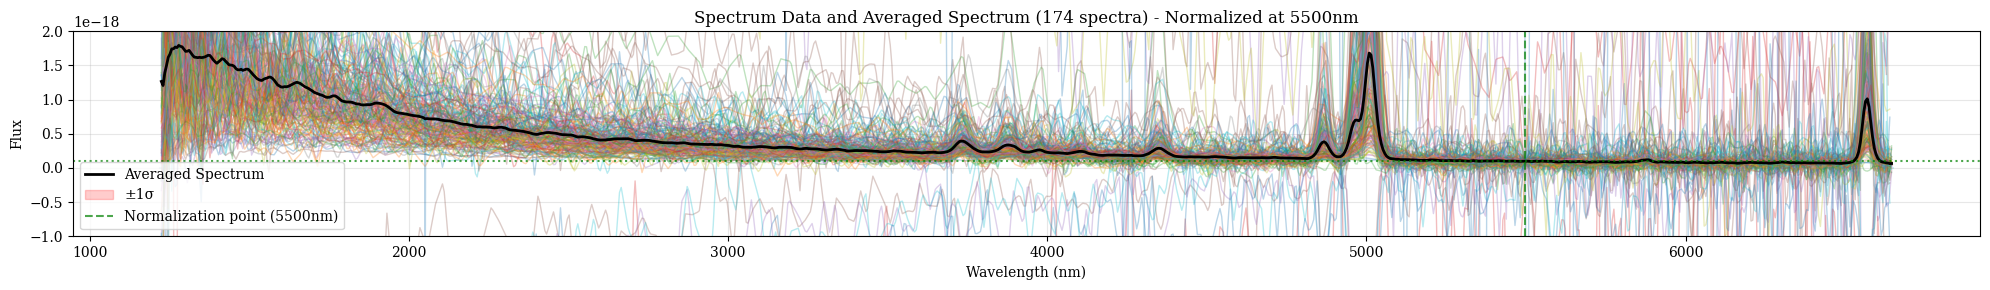

Calculating average for Balmer bin 1
成功处理 spectrum 0:
  波长范围: 975.84 - 9966.99
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 873.93 - 8926.10
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 986.46 - 10075.51
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 825.29 - 8429.33
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 860.63 - 8790.24
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 913.18 - 9327.01
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 861.60 - 8800.20
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 935.70 - 9556.99
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 998.60 - 10199.51
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 985.65 - 10067.23
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 873.40 - 8920.75
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 807.78 - 8250.46
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 828.27 - 8459.71
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 843.24 - 8612.62
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 867.64 - 8861.84
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 782.97 - 7997.03
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 808.45 - 8257.32
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 1070.26 -

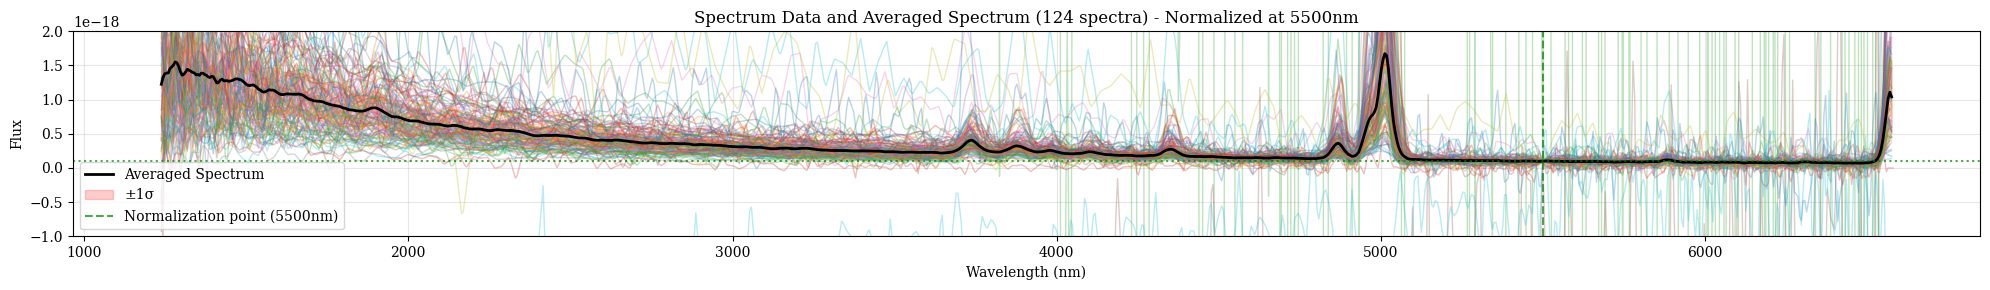

Calculating average for Balmer bin 2
成功处理 spectrum 0:
  波长范围: 1248.99 - 12756.87
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 1090.63 - 11139.48
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 857.32 - 8756.46
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 1012.43 - 10340.73
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 1003.62 - 10250.78
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 1012.41 - 10340.53
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 838.14 - 8560.62
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 996.18 - 10174.76
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 948.82 - 9691.08
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 999.97 - 10213.48
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 947.98 - 9682.49
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 927.12 - 9469.37
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 865.50 - 8839.97
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 859.31 - 8776.81
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 716.00 - 7313.11
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 655.53 - 6695.40
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 863.58 - 8820.39
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 

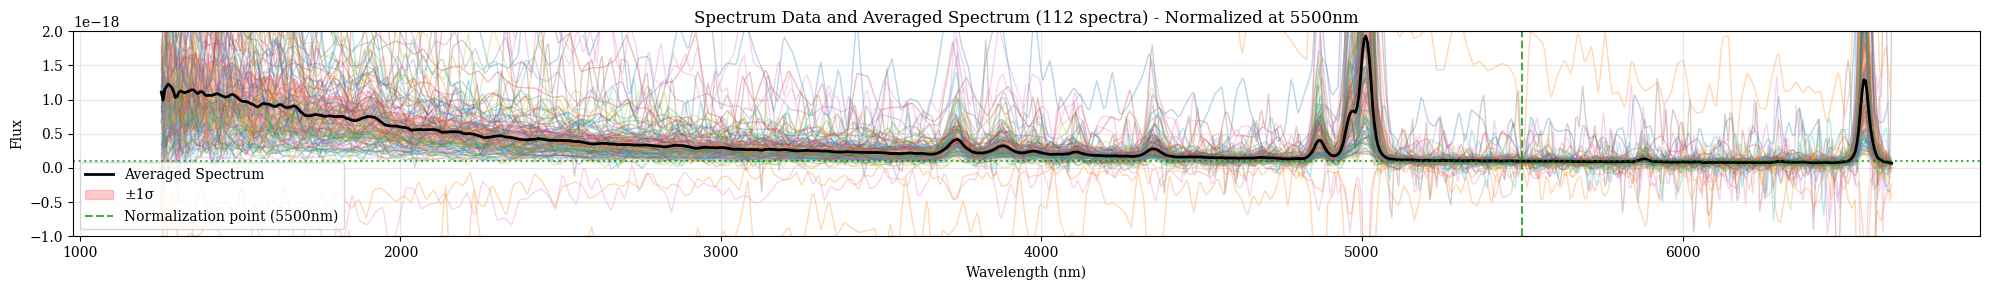

Calculating average for Balmer bin 3
成功处理 spectrum 0:
  波长范围: 1022.49 - 10443.52
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 678.35 - 6928.55
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 1217.45 - 12434.75
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 785.74 - 8025.37
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 828.46 - 8461.72
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 791.61 - 8085.37
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 792.49 - 8094.27
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 856.80 - 8751.12
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 859.28 - 8776.46
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 875.06 - 8937.67
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 861.00 - 8794.09
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 681.44 - 6960.07
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 865.48 - 8839.83
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 927.69 - 9475.23
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 1148.96 - 11735.22
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 680.84 - 6953.92
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 708.16 - 7232.98
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 888.54

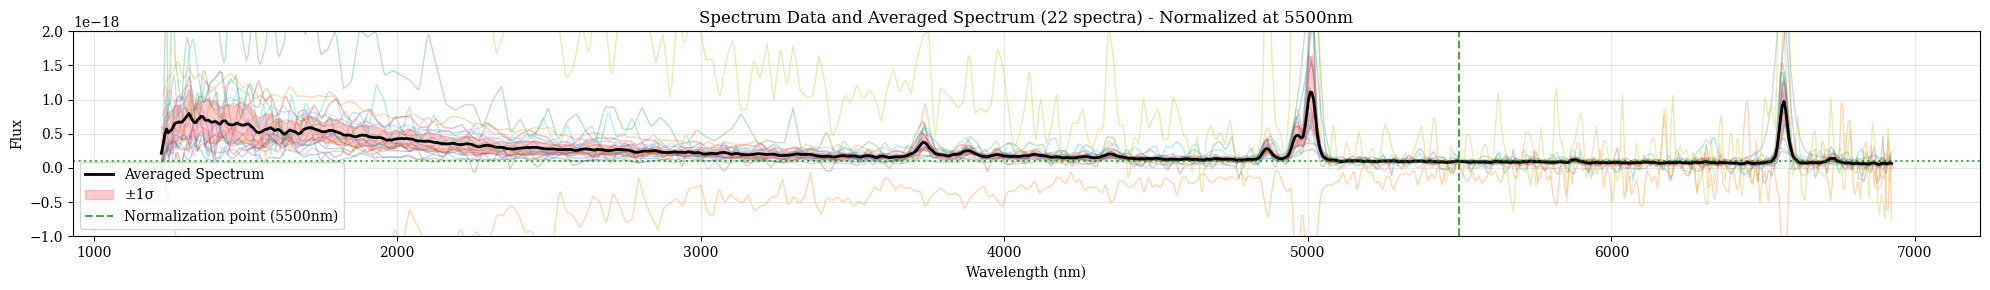

Calculating average for Balmer bin 4
成功处理 spectrum 0:
  波长范围: 870.20 - 8888.05
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 809.36 - 8266.66
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 866.91 - 8854.45
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 959.07 - 9795.73
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 858.97 - 8773.32
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 857.93 - 8762.66
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 944.72 - 9649.20
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 782.81 - 7995.47
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 678.96 - 6934.77
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 975.51 - 9963.66
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 827.24 - 8449.21
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 677.66 - 6921.50
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 982.43 - 10034.36
  数据点数: 473

总共成功处理了 13/13 个光谱

创建统一波长网格:
  波长范围: 982.43 - 6921.50
  插值点数: 1000
成功插值 13 个光谱

在 5500.64nm 处归一化到 1.00e-19
  Spectrum 0: 参考通量=7.22e-20, 归一化因子=1.38e+00
  Spectrum 1: 参考通量=1.69e-19, 归一化因子=5.93e-01
  Spectrum 2: 参考通量=2.42e-20, 归一化因子=4.13e+00
  Spectrum 3: 参考通

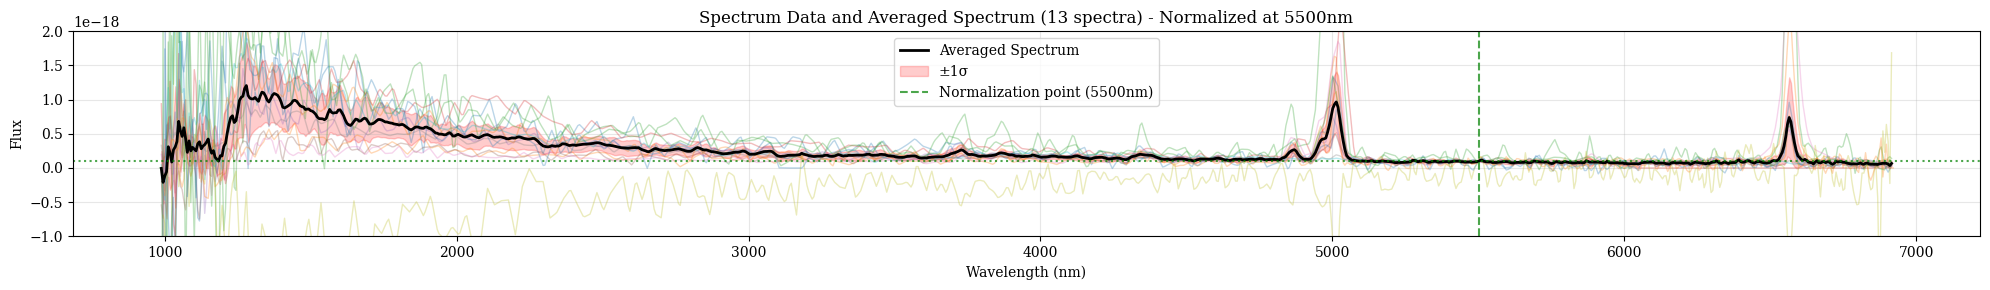

In [23]:
list_list=[balmer_bin0, balmer_bin1, balmer_bin2, balmer_bin3, balmer_bin4]
# 一键计算平均光谱

for i, spectrum_list in enumerate(list_list):
    print(f'Calculating average for Balmer bin {i}')
    # 一键计算平均光谱
    result = calculate_spectrum_average(
        spectrum_list=spectrum_list,
        interpolation_method='linear',
        average_method='mean',
        plot=True
    )

In [ ]:
def balmer_bin(balmer_decrement, bin_width=0.1, min_value=-1.0, max_value=1.0):
    """
    将Balmer衰减值分档到指定的区间

    参数:
    balmer_decrement: Balmer衰减值
    bin_width: 分档宽度，默认0.1
    min_value: 最小值，默认-1.0
    max_value: 最大值，默认1.0

    返回:
    bin_index: 分档索引，从0开始
    """
    if balmer_decrement < min_value:
        return -1  # 小于最小值的情况
    elif balmer_decrement >= max_value:
        return int((max_value - min_value) / bin_width)  # 大于等于最大值的情况
    else:
        return int((balmer_decrement - min_value) / bin_width)

def create_balmer_bins(catalog_iterator, load_spectrum_func,
                      bin_width=0.1, min_value=-1.0, max_value=1.0):
    """
    根据Balmer衰减值创建光谱分档

    参数:
    catalog_iterator: 目录迭代器
    load_spectrum_func: 加载光谱的函数
    bin_width: 分档宽度
    min_value: 最小值
    max_value: 最大值

    返回:
    dict: 包含各个分档的光谱列表和统计信息
    """
    # 计算总的分档数量
    num_bins = int((max_value - min_value) / bin_width) + 2  # +2 是为了包含边界情况

    # 初始化分档字典
    balmer_bins = {i: [] for i in range(-1, num_bins)}
    balmer_values = []

    print("开始处理光谱数据...")
    processed_count = 0

    for id, catalog in catalog_iterator:
        # 检查Sample_Flag
        if not catalog['properties']['Sample_Flag']:
            continue

        # 检查是否有Halpha和Hbeta拟合结果
        if ('Halpha_Fit_Result' not in catalog['properties'] or
            'Hbeta_Fit_Result' not in catalog['properties']):
            continue

        try:
            # 获取拟合结果
            halpha_result = catalog['properties']['Halpha_Fit_Result']
            hbeta_result = catalog['properties']['Hbeta_Fit_Result']

            # 计算强度
            halpha_intensity = halpha_result['integrated_flux']
            hbeta_intensity = hbeta_result['integrated_flux']

            # 计算Balmer衰减
            balmer = np.log(halpha_intensity / hbeta_intensity / 2.88)
            balmer_values.append(balmer)

            # 加载光谱
            prism_filepath = os.path.expanduser('~/' + catalog['prism_filepath'][16:])
            spectrum = load_spectrum_func(prism_filepath,
                                        catalog['determined_redshift'])

            # 确定分档
            bin_index = balmer_bin(balmer, bin_width, min_value, max_value)

            # 添加到对应分档
            if bin_index in balmer_bins:
                balmer_bins[bin_index].append(spectrum)

            processed_count += 1
            if processed_count % 100 == 0:
                print(f"已处理 {processed_count} 个光谱...")

        except Exception as e:
            print(f"处理光谱 {id} 时出错: {e}")
            continue

    # 打印统计信息
    print(f"\n光谱分档统计:")
    print(f"{'分档':<8} {'范围':<20} {'数量':<8}")
    print("-" * 40)

    total_spectra = 0
    valid_bins = {}

    for bin_idx in sorted(balmer_bins.keys()):
        count = len(balmer_bins[bin_idx])
        if count > 0:
            if bin_idx == -1:
                range_str = f"< {min_value:.1f}"
            elif bin_idx == num_bins - 1:
                range_str = f">= {max_value:.1f}"
            else:
                bin_start = min_value + bin_idx * bin_width
                bin_end = bin_start + bin_width
                range_str = f"[{bin_start:.1f}, {bin_end:.1f})"

            print(f"Bin {bin_idx:<3} {range_str:<20} {count:<8}")
            valid_bins[bin_idx] = balmer_bins[bin_idx]
            total_spectra += count

    print("-" * 40)
    print(f"总计: {total_spectra} 个光谱")

    # 统计Balmer值的分布
    if balmer_values:
        balmer_array = np.array(balmer_values)
        print(f"\nBalmer衰减值统计:")
        print(f"最小值: {np.min(balmer_array):.3f}")
        print(f"最大值: {np.max(balmer_array):.3f}")
        print(f"平均值: {np.mean(balmer_array):.3f}")
        print(f"标准差: {np.std(balmer_array):.3f}")

    return {
        'bins': valid_bins,
        'balmer_values': balmer_values,
        'bin_width': bin_width,
        'min_value': min_value,
        'max_value': max_value,
        'total_count': total_spectra
    }

# 使用示例

    # 替换为您的实际函数和迭代器
result = create_balmer_bins(
    catalog_iterator=DJAv4Catalog.catalog_iterator(),
    load_spectrum_func=FL.Load_Spectrum_From_Fits,
    bin_width=0.1,
    min_value=-1.0,
    max_value=1.0
)

    # 获取特定分档的光谱
    # bin_0_spectra = result['bins'][0]  # 获取第0档的光谱
    # bin_5_spectra = result['bins'][5]  # 获取第5档的光谱


for bin_idx, spectra_list in result['bins'].items():
    if len(spectra_list) > 0:
        print(f"\n计算分档 {bin_idx} 的平均光谱...")

        # 创建 SpectrumAverager 实例
        averager = SpectrumAverager()

        # 按步骤调用方法
        if averager.load_spectrum_list(spectra_list):
            averager.create_common_wavelength_grid()
            if averager.interpolate_all_spectra():
                averager.calculate_average_spectrum()
                averager.save_average_spectrum(f'balmer_bin_{bin_idx}_average.txt')
                # 可选：绘制图表
                averager.plot_spectra()
            else:
                print(f"分档 {bin_idx} 的插值失败")
        else:
            print(f"分档 {bin_idx} 的数据加载失败")


In [24]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
#1684
class SpectrumAverager:
    def __init__(self):
        """
        初始化光谱平均器
        """
        self.spectra_data = []
        self.common_wavelength = None
        self.interpolated_fluxes = []
        self.normalized_fluxes = []  # 新增：存储归一化后的通量
        self.average_flux = None
        self.std_flux = None
        self.normalization_factors = []  # 新增：存储归一化因子

    def load_spectrum_list(self, spectrum_list):
        """
        从spectrum对象列表加载所有光谱

        参数:
        spectrum_list: spectrum对象列表
        """
        self.spectra_data = []
        successful_loads = 0

        for i, spectrum in enumerate(spectrum_list):
            try:
                # 验证spectrum对象是否有必要的属性
                if not hasattr(spectrum, 'processing_wavelengths') or \
                   not hasattr(spectrum, 'processing_flux'):
                    print(f"警告: spectrum {i} - 缺少processing_wavelengths或processing_flux属性")
                    continue

                # 获取数据
                wl = np.array(spectrum.processing_wavelengths)
                flux = np.array(spectrum.processing_flux)

                # 检查数据有效性
                if len(wl) == 0 or len(flux) == 0:
                    print(f"警告: spectrum {i} - 波长或通量数据为空")
                    continue

                if len(wl) != len(flux):
                    print(f"警告: spectrum {i} - 波长和通量数据长度不匹配 ({len(wl)} vs {len(flux)})")
                    continue

                # 去除NaN值
                mask = ~(np.isnan(wl) | np.isnan(flux))
                if np.sum(mask) < 2:
                    print(f"警告: spectrum {i} - 有效数据点太少")
                    continue

                wl_clean = wl[mask]
                flux_clean = flux[mask]

                # 按波长排序
                sort_idx = np.argsort(wl_clean)
                wl_sorted = wl_clean[sort_idx]
                flux_sorted = flux_clean[sort_idx]

                self.spectra_data.append({
                    'index': i,
                    'spectrum': spectrum,
                    'wavelength': wl_sorted,
                    'flux': flux_sorted
                })

                successful_loads += 1
                print(f"成功处理 spectrum {i}:")
                print(f"  波长范围: {wl_sorted.min():.2f} - {wl_sorted.max():.2f}")
                print(f"  数据点数: {len(wl_sorted)}")

            except Exception as e:
                print(f"处理失败 spectrum {i}: {e}")

        print(f"\n总共成功处理了 {successful_loads}/{len(spectrum_list)} 个光谱")
        return successful_loads > 0

    def create_common_wavelength_grid(self, num_points=None, wavelength_range=None):
        """
        创建统一的波长网格

        参数:
        num_points: 插值点数 (None为自动选择)
        wavelength_range: 波长范围 (min_wl, max_wl) (None为自动选择交集)
        """
        if not self.spectra_data:
            raise ValueError("请先加载光谱数据")

        # 找出所有光谱的波长范围
        all_min_wl = [spec['wavelength'].min() for spec in self.spectra_data]
        all_max_wl = [spec['wavelength'].max() for spec in self.spectra_data]

        if wavelength_range is None:
            # 使用所有光谱的交集范围
            min_wl = max(all_min_wl)
            max_wl = min(all_max_wl)
        else:
            min_wl, max_wl = wavelength_range

        if min_wl >= max_wl:
            raise ValueError("所有光谱的波长范围没有交集，无法进行插值平均")

        if num_points is None:
            # 自动选择点数：使用所有光谱中最高的分辨率
            densities = []
            for spec in self.spectra_data:
                mask = (spec['wavelength'] >= min_wl) & (spec['wavelength'] <= max_wl)
                valid_points = np.sum(mask)
                if valid_points > 1:
                    densities.append(valid_points / (max_wl - min_wl))

            if densities:
                num_points = max(1000, int(max(densities) * (max_wl - min_wl)))
            else:
                num_points = 1000

        self.common_wavelength = np.linspace(min_wl, max_wl, num_points)

        print(f"\n创建统一波长网格:")
        print(f"  波长范围: {min_wl:.2f} - {max_wl:.2f}")
        print(f"  插值点数: {num_points}")

        return self.common_wavelength

    def interpolate_all_spectra(self, interpolation_method='linear'):
        """
        对所有光谱进行插值到统一网格

        参数:
        interpolation_method: 插值方法 ('linear', 'cubic', 'quadratic')
        """
        if self.common_wavelength is None:
            self.create_common_wavelength_grid()

        self.interpolated_fluxes = []
        successful_interpolations = 0

        for spec_data in self.spectra_data:
            try:
                wl = spec_data['wavelength']
                flux = spec_data['flux']

                # 找出在公共波长范围内的数据点
                mask = (wl >= self.common_wavelength.min()) & \
                       (wl <= self.common_wavelength.max())

                if np.sum(mask) < 2:
                    print(f"警告: spectrum {spec_data['index']} 在公共波长范围内的数据点太少，跳过")
                    continue

                wl_subset = wl[mask]
                flux_subset = flux[mask]

                # 创建插值函数
                interp_func = interp1d(wl_subset, flux_subset,
                                     kind=interpolation_method,
                                     bounds_error=False,
                                     fill_value=np.nan)

                # 进行插值
                interpolated_flux = interp_func(self.common_wavelength)

                # 检查插值结果
                if np.all(np.isnan(interpolated_flux)):
                    print(f"警告: spectrum {spec_data['index']} 插值结果全为NaN，跳过")
                    continue

                self.interpolated_fluxes.append(interpolated_flux)
                successful_interpolations += 1

            except Exception as e:
                print(f"插值失败 spectrum {spec_data['index']}: {e}")

        print(f"成功插值 {successful_interpolations} 个光谱")
        return successful_interpolations > 0

    def normalize_at_wavelength(self, reference_wavelength=5500.0, target_flux=1e-19):
        """
        将所有光谱在指定波长处归一化到目标通量值

        参数:
        reference_wavelength: 参考波长 (默认550nm)
        target_flux: 目标通量值 (默认1e-19)
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        # 检查参考波长是否在波长范围内
        if reference_wavelength < self.common_wavelength.min() or \
           reference_wavelength > self.common_wavelength.max():
            raise ValueError(f"参考波长 {reference_wavelength}nm 超出波长范围 "
                           f"[{self.common_wavelength.min():.1f}, {self.common_wavelength.max():.1f}]")

        # 找到最接近参考波长的索引
        ref_idx = np.argmin(np.abs(self.common_wavelength - reference_wavelength))
        actual_ref_wavelength = self.common_wavelength[ref_idx]

        print(f"\n在 {actual_ref_wavelength:.2f}nm 处归一化到 {target_flux:.2e}")

        self.normalized_fluxes = []
        self.normalization_factors = []
        successful_normalizations = 0

        for i, flux in enumerate(self.interpolated_fluxes):
            try:
                # 获取参考波长处的通量值
                ref_flux = flux[ref_idx]

                # 检查参考通量是否有效
                if np.isnan(ref_flux) or ref_flux == 0:
                    print(f"警告: spectrum {i} 在参考波长处通量无效 ({ref_flux})，跳过归一化")
                    continue

                # 计算归一化因子
                normalization_factor = target_flux / ref_flux

                # 应用归一化
                normalized_flux = flux * normalization_factor

                self.normalized_fluxes.append(normalized_flux)
                self.normalization_factors.append(normalization_factor)
                successful_normalizations += 1

                print(f"  Spectrum {i}: 参考通量={ref_flux:.2e}, 归一化因子={normalization_factor:.2e}")

            except Exception as e:
                print(f"归一化失败 spectrum {i}: {e}")

        print(f"成功归一化 {successful_normalizations} 个光谱")

        # 更新插值通量为归一化后的通量
        if self.normalized_fluxes:
            self.interpolated_fluxes = self.normalized_fluxes.copy()

        return successful_normalizations > 0

    def calculate_average_spectrum(self, method='mean', ignore_nan=True,
                                 use_percentile_filter=False, lower_percentile=16, upper_percentile=84):
        """
        计算平均光谱

        参数:
        method: 平均方法 ('mean', 'median')
        ignore_nan: 是否忽略NaN值
        use_percentile_filter: 是否使用分位数过滤异常值
        lower_percentile: 下分位数 (默认16%)
        upper_percentile: 上分位数 (默认84%)
        """
        if not self.interpolated_fluxes:
            raise ValueError("请先进行插值")

        flux_matrix = np.array(self.interpolated_fluxes)

        if use_percentile_filter:
            # 使用分位数过滤方法
            self.average_flux, self.std_flux = self._calculate_percentile_filtered_average(
                flux_matrix, method, ignore_nan, lower_percentile, upper_percentile)
        else:
            # 传统方法
            if ignore_nan:
                if method == 'mean':
                    self.average_flux = np.nanmean(flux_matrix, axis=0)
                    self.std_flux = np.nanstd(flux_matrix, axis=0)
                elif method == 'median':
                    self.average_flux = np.nanmedian(flux_matrix, axis=0)
                    self.std_flux = np.nanstd(flux_matrix, axis=0)
            else:
                if method == 'mean':
                    self.average_flux = np.mean(flux_matrix, axis=0)
                    self.std_flux = np.std(flux_matrix, axis=0)
                elif method == 'median':
                    self.average_flux = np.median(flux_matrix, axis=0)
                    self.std_flux = np.std(flux_matrix, axis=0)

        # 计算每个波长点的有效光谱数量
        valid_count = np.sum(~np.isnan(flux_matrix), axis=0) if ignore_nan else len(self.interpolated_fluxes)

        filter_info = f" (分位数过滤: {lower_percentile}-{upper_percentile}%)" if use_percentile_filter else ""
        print(f"\n使用 {method} 方法计算平均光谱 (ignore_nan={ignore_nan}){filter_info}")
        print(f"平均每个波长点有 {np.mean(valid_count):.1f} 个有效光谱参与计算")

        return self.common_wavelength, self.average_flux, self.std_flux

    def _calculate_percentile_filtered_average(self, flux_matrix, method, ignore_nan,
                                             lower_percentile, upper_percentile):
        """
        使用分位数过滤计算平均光谱

        参数:
        flux_matrix: 通量矩阵 (n_spectra x n_wavelengths)
        method: 平均方法
        ignore_nan: 是否忽略NaN
        lower_percentile, upper_percentile: 分位数范围

        返回:
        average_flux, std_flux: 平均通量和标准差
        """
        n_spectra, n_wavelengths = flux_matrix.shape
        average_flux = np.full(n_wavelengths, np.nan)
        std_flux = np.full(n_wavelengths, np.nan)

        total_kept_points = 0
        total_original_points = 0

        # 对每个波长点分别处理
        for i in range(n_wavelengths):
            wavelength_fluxes = flux_matrix[:, i]

            # 处理NaN值
            if ignore_nan:
                valid_mask = ~np.isnan(wavelength_fluxes)
                valid_fluxes = wavelength_fluxes[valid_mask]
            else:
                valid_fluxes = wavelength_fluxes

            # 如果有效数据点太少，跳过
            if len(valid_fluxes) < 3:  # 至少需要3个点才能进行分位数过滤
                continue

            total_original_points += len(valid_fluxes)

            # 计算分位数
            try:
                lower_bound = np.percentile(valid_fluxes, lower_percentile)
                upper_bound = np.percentile(valid_fluxes, upper_percentile)

                # 过滤异常值
                filtered_mask = (valid_fluxes >= lower_bound) & (valid_fluxes <= upper_bound)
                filtered_fluxes = valid_fluxes[filtered_mask]

                # 确保至少保留一些数据点
                if len(filtered_fluxes) < 1:
                    # 如果过滤后没有数据，使用原始数据
                    filtered_fluxes = valid_fluxes

                total_kept_points += len(filtered_fluxes)

                # 计算统计量
                if method == 'mean':
                    average_flux[i] = np.mean(filtered_fluxes)
                elif method == 'median':
                    average_flux[i] = np.median(filtered_fluxes)

                # 计算标准差（基于过滤后的数据）
                if len(filtered_fluxes) > 1:
                    std_flux[i] = np.std(filtered_fluxes)
                else:
                    std_flux[i] = 0.0

            except Exception as e:
                # 如果分位数计算失败，跳过该波长点
                continue

        # 统计信息
        filter_efficiency = (total_kept_points / total_original_points * 100) if total_original_points > 0 else 0
        print(f"分位数过滤统计:")
        print(f"  保留数据点: {total_kept_points}/{total_original_points} ({filter_efficiency:.1f}%)")
        print(f"  过滤掉的异常值: {total_original_points - total_kept_points} ({100-filter_efficiency:.1f}%)")

        return average_flux, std_flux

    def plot_spectra(self, show_individual=True, show_average=True,
                    show_std=True, figsize=(20,3), alpha=0.3,
                    show_normalization_point=True, reference_wavelength=5500):
        """
        绘制光谱图

        参数:
        show_normalization_point: 是否显示归一化参考点
        reference_wavelength: 参考波长
        """
        plt.figure(figsize=figsize)

        if show_individual and self.interpolated_fluxes:
            # 绘制个别光谱
            for i, flux in enumerate(self.interpolated_fluxes):
                label = None
                if len(self.interpolated_fluxes) <= 5:
                    # 只有少量光谱时才显示标签
                    label = f'Spectrum {i+1}'
                plt.plot(self.common_wavelength, flux,
                        alpha=alpha, linewidth=1, label=label)

        if show_average and self.average_flux is not None:
            # 绘制平均光谱
            plt.plot(self.common_wavelength, self.average_flux,
                    'k-', linewidth=2, label='Averaged Spectrum')

            if show_std and self.std_flux is not None:
                # 绘制标准差区域
                plt.fill_between(self.common_wavelength,
                               self.average_flux - self.std_flux,
                               self.average_flux + self.std_flux,
                               alpha=0.2, color='red', label='±1σ')

        # 显示归一化参考点
        if show_normalization_point and self.normalization_factors:
            ref_idx = np.argmin(np.abs(self.common_wavelength - reference_wavelength))
            plt.axvline(x=self.common_wavelength[ref_idx], color='green',
                       linestyle='--', alpha=0.7, label=f'Normalization point ({reference_wavelength}nm)')
            plt.axhline(y=1e-19, color='green', linestyle=':', alpha=0.7)

        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Flux')
        plt.ylim(-1e-18, 2e-18)

        title = f'Spectrum Data and Averaged Spectrum ({len(self.interpolated_fluxes)} spectra)'
        if self.normalization_factors:
            title += f' - Normalized at {reference_wavelength}nm'
        plt.title(title)

        plt.grid(True, alpha=0.3)

        if (len(self.interpolated_fluxes) <= 10) or show_average or show_normalization_point:
            plt.legend()

        plt.tight_layout()
        plt.show()

    def get_normalization_info(self):
        """
        返回归一化信息

        返回:
        dict: 包含归一化因子等信息的字典
        """
        return {
            'normalization_factors': self.normalization_factors.copy() if self.normalization_factors else None,
            'num_normalized_spectra': len(self.normalization_factors),
            'factor_mean': np.mean(self.normalization_factors) if self.normalization_factors else None,
            'factor_std': np.std(self.normalization_factors) if self.normalization_factors else None
        }

    def get_average_spectrum_data(self):
        """
        返回平均光谱数据

        返回:
        dict: 包含wavelength, flux, std的字典
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        return {
            'wavelength': self.common_wavelength.copy(),
            'flux': self.average_flux.copy(),
            'std': self.std_flux.copy() if self.std_flux is not None else None,
            'normalization_info': self.get_normalization_info()
        }

    def save_average_spectrum(self, filename, include_std=True):
        """
        保存平均光谱到文件
        """
        if self.average_flux is None:
            raise ValueError("请先计算平均光谱")

        if include_std and self.std_flux is not None:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux,
                                  self.std_flux])
            header = "Wavelength\tFlux\tStd"
        else:
            data = np.column_stack([self.common_wavelength,
                                  self.average_flux])
            header = "Wavelength\tFlux"

        np.savetxt(filename, data, delimiter='\t', header=header, comments='')
        print(f"平均光谱已保存到: {filename}")

def calculate_spectrum_average(spectrum_list,
                             num_points=None, wavelength_range=None,
                             interpolation_method='linear', average_method='mean',
                             normalize_at_550nm=True, target_flux=1e-19,
                             use_percentile_filter=True, lower_percentile=16, upper_percentile=84,
                             plot=True, save_file=None):
    """
    便捷函数：一键计算光谱平均值

    参数:
    spectrum_list: spectrum对象列表
    num_points: 插值点数
    wavelength_range: 波长范围
    interpolation_method: 插值方法
    average_method: 平均方法
    normalize_at_550nm: 是否在550nm处归一化
    target_flux: 归一化目标通量值
    use_percentile_filter: 是否使用分位数过滤异常值
    lower_percentile: 下分位数 (默认16%)
    upper_percentile: 上分位数 (默认84%)
    plot: 是否绘图
    save_file: 保存文件名

    返回:
    dict: 包含wavelength, flux, std的字典
    """
    # 创建平均器
    averager = SpectrumAverager()

    # 加载数据
    if not averager.load_spectrum_list(spectrum_list):
        raise ValueError("没有成功处理任何光谱对象")

    # 创建波长网格
    averager.create_common_wavelength_grid(num_points, wavelength_range)

    # 插值
    if not averager.interpolate_all_spectra(interpolation_method):
        raise ValueError("插值失败")

    # 归一化处理
    if normalize_at_550nm:
        if not averager.normalize_at_wavelength(5500, target_flux):
            print("警告: 归一化失败，继续使用原始数据计算平均值")

    # 计算平均（使用分位数过滤）
    averager.calculate_average_spectrum(average_method, ignore_nan=True,
                                      use_percentile_filter=use_percentile_filter,
                                      lower_percentile=lower_percentile,
                                      upper_percentile=upper_percentile)

    # 绘图
    if plot:
        averager.plot_spectra(show_normalization_point=normalize_at_550nm)

    # 保存
    if save_file:
        averager.save_average_spectrum(save_file)

    return averager.get_average_spectrum_data()

Calculating average for Balmer bin 0
成功处理 spectrum 0:
  波长范围: 867.95 - 8865.05
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 813.71 - 8311.01
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 909.17 - 9286.02
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 881.78 - 9006.26
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 871.22 - 8898.45
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 850.61 - 8687.91
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 897.56 - 9167.49
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 917.54 - 9371.54
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 913.37 - 9328.90
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 853.92 - 8721.71
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 986.40 - 10074.86
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 925.77 - 9455.57
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 997.25 - 10185.66
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 948.23 - 9685.04
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 995.69 - 10169.70
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 858.71 - 8770.67
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 917.27 - 9368.76
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 929.76 - 

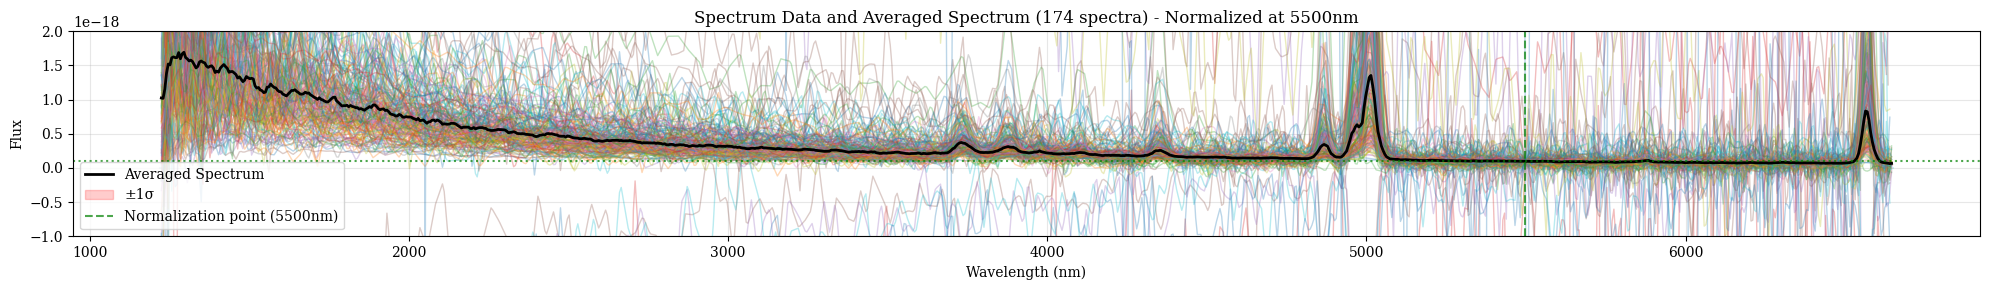

Calculating average for Balmer bin 1
成功处理 spectrum 0:
  波长范围: 975.84 - 9966.99
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 873.93 - 8926.10
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 986.46 - 10075.51
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 825.29 - 8429.33
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 860.63 - 8790.24
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 913.18 - 9327.01
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 861.60 - 8800.20
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 935.70 - 9556.99
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 998.60 - 10199.51
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 985.65 - 10067.23
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 873.40 - 8920.75
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 807.78 - 8250.46
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 828.27 - 8459.71
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 843.24 - 8612.62
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 867.64 - 8861.84
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 782.97 - 7997.03
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 808.45 - 8257.32
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 1070.26 -

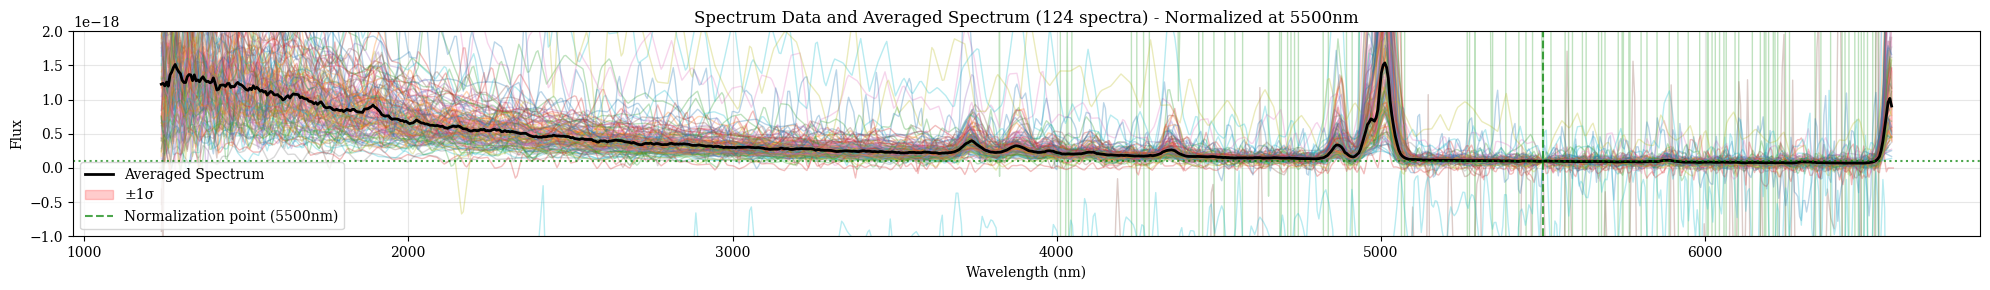

Calculating average for Balmer bin 2
成功处理 spectrum 0:
  波长范围: 1248.99 - 12756.87
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 1090.63 - 11139.48
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 857.32 - 8756.46
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 1012.43 - 10340.73
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 1003.62 - 10250.78
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 1012.41 - 10340.53
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 838.14 - 8560.62
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 996.18 - 10174.76
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 948.82 - 9691.08
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 999.97 - 10213.48
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 947.98 - 9682.49
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 927.12 - 9469.37
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 865.50 - 8839.97
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 859.31 - 8776.81
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 716.00 - 7313.11
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 655.53 - 6695.40
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 863.58 - 8820.39
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 

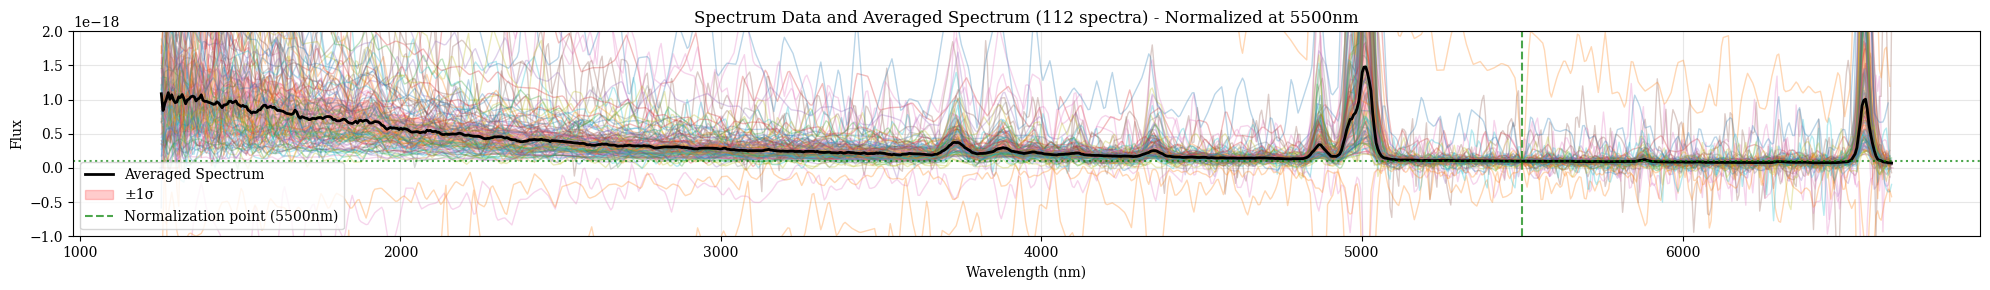

Calculating average for Balmer bin 3
成功处理 spectrum 0:
  波长范围: 1022.49 - 10443.52
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 678.35 - 6928.55
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 1217.45 - 12434.75
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 785.74 - 8025.37
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 828.46 - 8461.72
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 791.61 - 8085.37
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 792.49 - 8094.27
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 856.80 - 8751.12
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 859.28 - 8776.46
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 875.06 - 8937.67
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 861.00 - 8794.09
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 681.44 - 6960.07
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 865.48 - 8839.83
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 927.69 - 9475.23
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 1148.96 - 11735.22
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 680.84 - 6953.92
  数据点数: 473
成功处理 spectrum 16:
  波长范围: 708.16 - 7232.98
  数据点数: 473
成功处理 spectrum 17:
  波长范围: 888.54

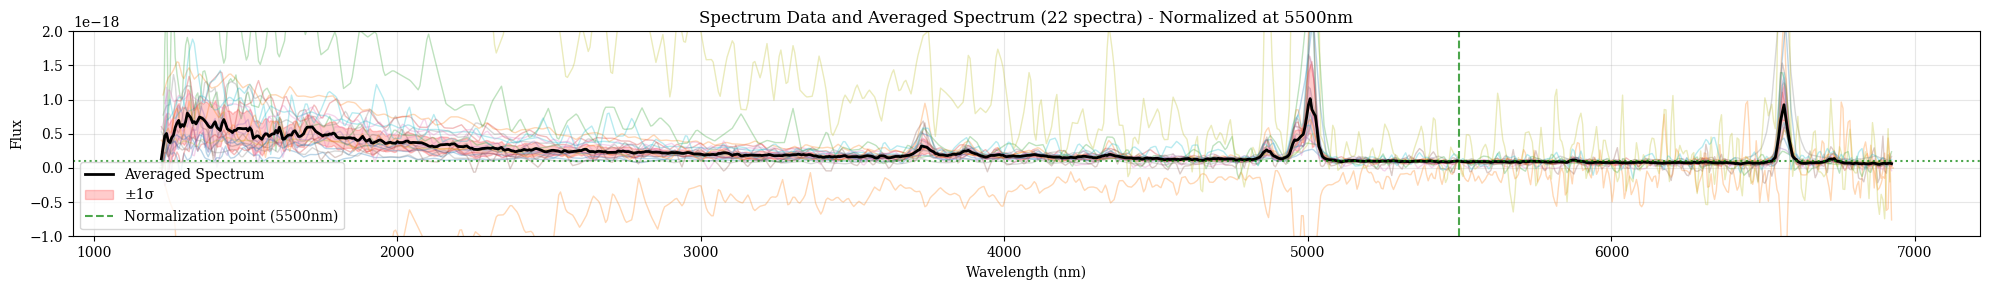

Calculating average for Balmer bin 4
成功处理 spectrum 0:
  波长范围: 870.20 - 8888.05
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 809.36 - 8266.66
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 866.91 - 8854.45
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 959.07 - 9795.73
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 858.97 - 8773.32
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 857.93 - 8762.66
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 944.72 - 9649.20
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 782.81 - 7995.47
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 678.96 - 6934.77
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 975.51 - 9963.66
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 827.24 - 8449.21
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 677.66 - 6921.50
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 982.43 - 10034.36
  数据点数: 473

总共成功处理了 13/13 个光谱

创建统一波长网格:
  波长范围: 982.43 - 6921.50
  插值点数: 1000
成功插值 13 个光谱

在 5500.64nm 处归一化到 1.00e-19
  Spectrum 0: 参考通量=7.22e-20, 归一化因子=1.38e+00
  Spectrum 1: 参考通量=1.69e-19, 归一化因子=5.93e-01
  Spectrum 2: 参考通量=2.42e-20, 归一化因子=4.13e+00
  Spectrum 3: 参考通

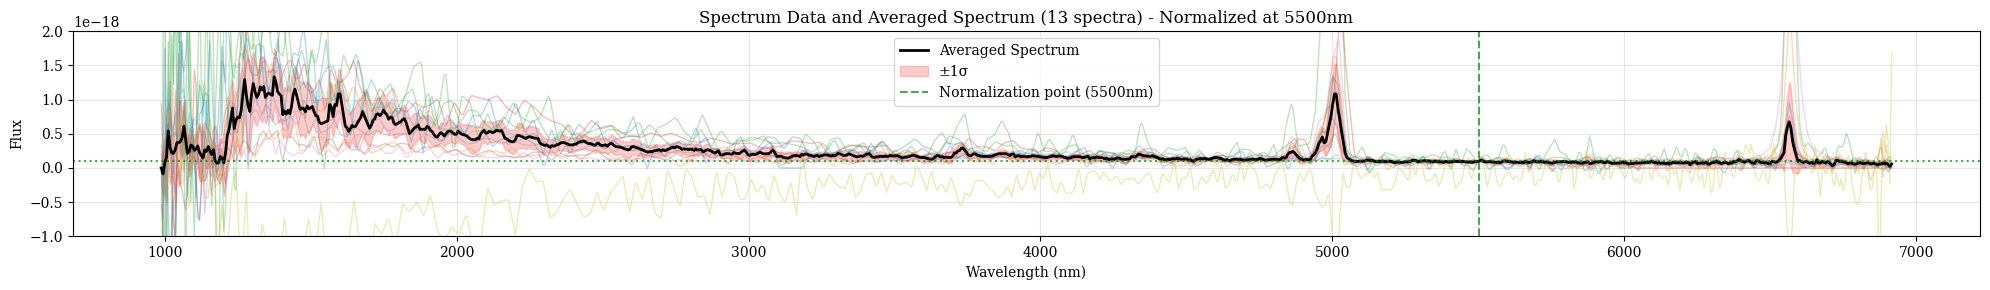

In [25]:
list_list = [balmer_bin0, balmer_bin1, balmer_bin2, balmer_bin3, balmer_bin4]

for i, spectrum_list in enumerate(list_list):
    print(f'Calculating average for Balmer bin {i}')
    result = calculate_spectrum_average(
        spectrum_list=spectrum_list,
        interpolation_method='linear',
        average_method='median',
        normalize_at_550nm=True,
        use_percentile_filter=True,  # 默认True，使用16%-84%过滤
        # lower_percentile=25,
        # upper_percentile=75,
        plot=True
    )

In [14]:
# 1. Combine the necessary spectrum lists, excluding bin 1.
spectra_for_f1 = balmer_bin0
spectra_for_fn = balmer_bin2 + balmer_bin3 + balmer_bin4
combined_spectra = spectra_for_f1 + spectra_for_fn

num_f1 = len(spectra_for_f1)
num_fn = len(spectra_for_fn)

print(f"Number of spectra for F1 (bin 0): {num_f1}")
print(f"Number of spectra for Fn (bins 2, 3, 4): {num_fn}")
print(f"Total spectra being processed: {len(combined_spectra)}")

# 2. Perform unified pre-processing using the SpectrumAverager class.
processor = SpectrumAverager()

# Load, create grid, interpolate, and normalize all spectra together.
processor.load_spectrum_list(combined_spectra)
common_wavelength = processor.create_common_wavelength_grid()
processor.interpolate_all_spectra()
processor.normalize_at_wavelength(reference_wavelength=5500.0)

# Retrieve all the processed fluxes as a NumPy array.
all_processed_fluxes = np.array(processor.interpolated_fluxes)
print(f"\nUnified pre-processing complete on a common grid from {common_wavelength.min():.1f} to {common_wavelength.max():.1f} Å.")

# 3. Separate the processed fluxes back into their respective groups.
processed_fluxes_f1_group = all_processed_fluxes[0:num_f1, :]
processed_fluxes_fn_group = all_processed_fluxes[num_f1:, :]

# 4. Calculate the reference spectrum F1(λ) with 16-84 percentile filtering.
print("\nCalculating the reference spectrum F1(λ) from bin 0...")
F1_flux, _ = processor._calculate_percentile_filtered_average(
    flux_matrix=processed_fluxes_f1_group,
    method='mean',
    ignore_nan=True,
    lower_percentile=16,
    upper_percentile=84
)

# 5. Calculate Qe(λ) using the provided formula.
print("Calculating the total extinction curve Qe(λ)...")

# To avoid log(0) errors, replace non-positive values with a small number.
epsilon = 1e-30
F1_flux_safe = np.maximum(F1_flux, epsilon)
processed_fluxes_fn_group_safe = np.maximum(processed_fluxes_fn_group, epsilon)

# Using the numerically stable form: Qe = N*ln(F1) - Σ(ln(Fn))
log_f1 = np.log(F1_flux_safe)
sum_log_fn = np.nansum(np.log(processed_fluxes_fn_group_safe), axis=0)
N_fn = processed_fluxes_fn_group.shape[0]
Qe = N_fn * log_f1 - sum_log_fn

print("Calculation complete.")

Number of spectra for F1 (bin 0): 174
Number of spectra for Fn (bins 2, 3, 4): 148
Total spectra being processed: 322
成功处理 spectrum 0:
  波长范围: 867.95 - 8865.05
  数据点数: 473
成功处理 spectrum 1:
  波长范围: 813.71 - 8311.01
  数据点数: 473
成功处理 spectrum 2:
  波长范围: 909.17 - 9286.02
  数据点数: 473
成功处理 spectrum 3:
  波长范围: 881.78 - 9006.26
  数据点数: 473
成功处理 spectrum 4:
  波长范围: 871.22 - 8898.45
  数据点数: 473
成功处理 spectrum 5:
  波长范围: 850.61 - 8687.91
  数据点数: 473
成功处理 spectrum 6:
  波长范围: 897.56 - 9167.49
  数据点数: 473
成功处理 spectrum 7:
  波长范围: 917.54 - 9371.54
  数据点数: 473
成功处理 spectrum 8:
  波长范围: 913.37 - 9328.90
  数据点数: 473
成功处理 spectrum 9:
  波长范围: 853.92 - 8721.71
  数据点数: 473
成功处理 spectrum 10:
  波长范围: 986.40 - 10074.86
  数据点数: 473
成功处理 spectrum 11:
  波长范围: 925.77 - 9455.57
  数据点数: 473
成功处理 spectrum 12:
  波长范围: 997.25 - 10185.66
  数据点数: 473
成功处理 spectrum 13:
  波长范围: 948.23 - 9685.04
  数据点数: 473
成功处理 spectrum 14:
  波长范围: 995.69 - 10169.70
  数据点数: 473
成功处理 spectrum 15:
  波长范围: 858.71 - 8770.67
  数据点数: 473
成功处理 spec

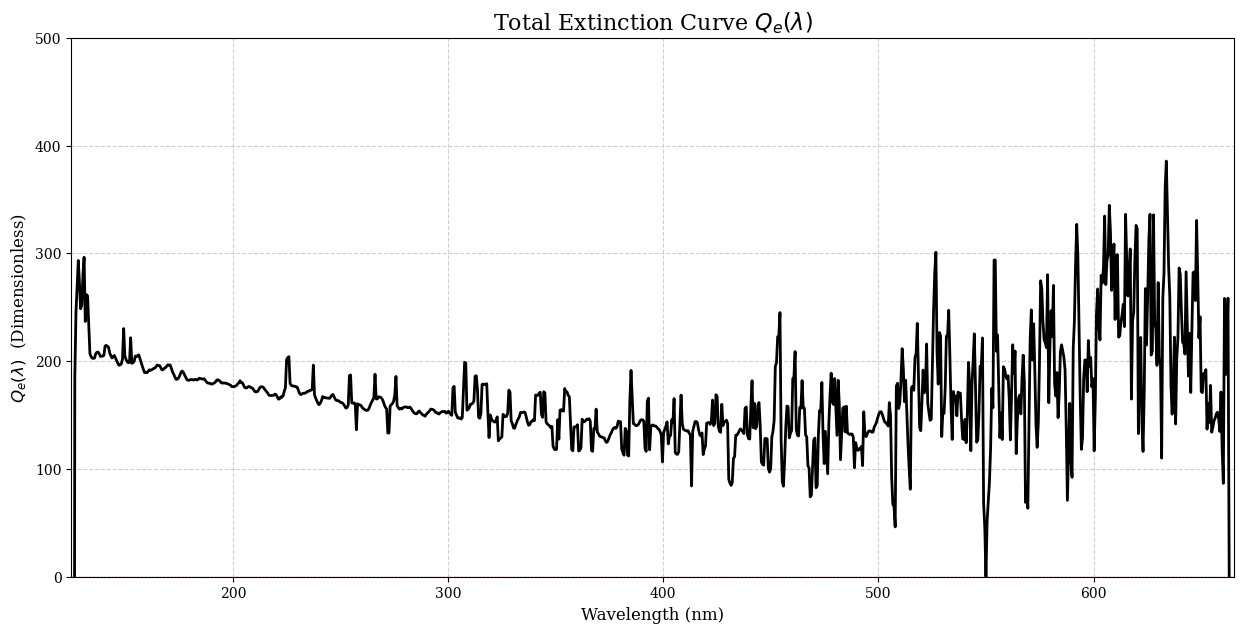

In [19]:
# Plot the final result
plt.figure(figsize=(15, 7))
plt.plot(common_wavelength/10, Qe, color='black', linewidth=2) # Convert Å to nm for plotting
plt.title('Total Extinction Curve $Q_e(\lambda)$', fontsize=16)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('$Q_e(\lambda)$  (Dimensionless)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='red', linestyle=':', linewidth=1)
plt.xlim((common_wavelength.min()/10, common_wavelength.max()/10))
plt.ylim(0,500)
plt.show()